# **SVR Optuna**

Sama dengan yang SVR GridSearchCV, hanya saja GridSearchCV diganti menggunakan Optuna

In [22]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Load dan Split Data**

Sama persis dengan SVR GridSearchCV

In [23]:
from sklearn.preprocessing import StandardScaler

processed_file = os.path.join("..", "..", "data", "processed", "ihsg_processed_1.csv")
if not os.path.exists(processed_file):
    raise FileNotFoundError(f"File {processed_file} tidak ditemukan. Jalankan Data_Preparation.ipynb dulu!")
    
df = pd.read_csv(processed_file, index_col=0, parse_dates=True)
df = df.sort_index()

feature_cols = ['EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', 'MACD_signal']
target_col = 'Target_Close'

X = df[feature_cols]
y = df[target_col]

total_rows = len(df)
train_end = int(total_rows * 0.70)
val_end = train_end + int(total_rows * 0.15)

X_train_raw, y_train_raw = X.iloc[:train_end], y.iloc[:train_end]
X_val_raw, y_val_raw = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test_raw, y_test_raw = X.iloc[val_end:], y.iloc[val_end:]

scalerX = StandardScaler()
scalery = StandardScaler()

X_train = pd.DataFrame(scalerX.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_val = pd.DataFrame(scalerX.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)
X_test = pd.DataFrame(scalerX.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

y_train = pd.Series(scalery.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten(), index=y_train_raw.index)
y_val = pd.Series(scalery.transform(y_val_raw.values.reshape(-1, 1)).flatten(), index=y_val_raw.index)
y_test = y_test_raw 

print(f"Data Shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Data Shapes - Train: (2695, 7), Val: (577, 7), Test: (579, 7)


### **Training Model SVR dengan Optuna**

In [24]:
import optuna
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning

# Entah kenapa ada warning panjang soal consider data untuk di scalling. Padahal di atas udah di scale, jadi untuk memperbagus notebook nya, warning nya di ignore aja.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1.0, 10000.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.001, 10.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.0001, 0.1, log=True),
        'kernel': 'rbf'
    }
    model = SVR(**params, max_iter=50000)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    return mean_squared_error(y_val, val_preds)

start_time = time.time()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
execution_time = time.time() - start_time

print(f"Waktu Eksekusi: {execution_time:.2f} detik")
print(f"Parameter Terbaik: {study.best_params}")

best_params = study.best_params
best_params['kernel'] = 'rbf'

best_model = SVR(**best_params)
best_model.fit(X_train, y_train)


  0%|          | 0/50 [00:00<?, ?it/s]

Waktu Eksekusi: 65.01 detik
Parameter Terbaik: {'C': 290.18441172627695, 'gamma': 0.004910720408726574, 'epsilon': 0.0001821792464940043}


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.004910720408726574
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",290.18441172627695
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.0001821792464940043
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


Dapat dilihat dari waktu eksekusi nya, dibandingkan dengan SVR GridSearch CV (111 s), Optuna hanya membutuhkan 65 s. Itu hampir 2x lebih cepat.

### **Evaluation and Save**

Evaluasi akan menggunakan 5 metric:
1. MAPE (Mean Absolute Percentage Error): Mengukur seberapa jauh atau akurat sebuah model prediksi dalam memperkirakan suatu nilai, dan hasilnya dinyatakan dalam bentuk persentase.
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

2. MSE (Mean Squared Error): $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

3. RMSE (Root Mean Squared Error): $$RMSE = \sqrt{MSE}$$

4. MAE (Mean Absolute Error): $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

5. Hit Rate: Menghitung seberapa akurat model menebak arah pergerakan pasar.
$$\text{Hit Rate} = \left( \frac{1}{N} \sum_{i=1}^{N} I \left( \text{sgn}(\hat{y}_{i+1} - y_i) = \text{sgn}(y_{i+1} - y_i) \right) \right) \times 100\%$$

Keterangan untuk hit rate:
* $N$ = Jumlah total pengujian langkah pergerakan harga yang valid.
* $I$ = Fungsi indikator (bernilai 1 jika arah tebakan benar, dan 0 jika salah).
* $\text{sgn}$ = Fungsi *sign* (mendeteksi apakah pergerakan harian naik atau turun).
* $\hat{y}_{i+1}$ = Harga prediksi untuk hari esok.
* $y_{i+1}$ = Harga penutupan aktual hari esok.
* $y_i$ = Harga penutupan aktual hari ini.

In [25]:
import json
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [26]:
test_preds_scaled = best_model.predict(X_test)
test_preds = scalery.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

# MAPE
actual = y_test.values
percentage_errors = np.abs((test_preds - actual) / actual) * 100
mape = np.mean(percentage_errors)
print(f"MAPE: {mape:.4f}%")

# MSE
test_mse = mean_squared_error(y_test, test_preds)
print(f"MSE: {test_mse:.4f}")

# RMSE
test_rmse = np.sqrt(test_mse)
print(f"RMSE: {test_rmse:.4f}")

# MAE
mae = mean_absolute_error(actual, test_preds)
print(f"MAE: {mae:.4f}")

# Hit Rate
arah_aktual = np.sign(actual[1:] - actual[:-1])
arah_prediksi = np.sign(test_preds[1:] - actual[:-1])

valid_idx = arah_aktual != 0 
hit_rate = (arah_prediksi[valid_idx] == arah_aktual[valid_idx]).mean() * 100
print(f"Hit Rate: {hit_rate:.4f}%")

# Save metrics model, scaler
metrics_results = {
    "method": "Optuna",
    "execution_time_seconds": execution_time,
    "best_params": best_params,
    "best_validation_mse": float(study.best_value),
    "test_mse": float(test_mse),
    "test_rmse": float(test_rmse),
    "test_mae": float(mae),
    "mape": float(mape),
    "hit_rate_percentage": float(hit_rate)
}

with open(os.path.join("..", "..", "outputs", "metrics", "SVR_optuna_metrics.json"), "w") as f:
    json.dump(metrics_results, f, indent=4)

joblib.dump(best_model, (os.path.join("..", "..", "outputs", "models", "SVR_optuna_model.pkl")))
joblib.dump(scalerX, os.path.join("..", "..", "outputs", "models", "scalerX.pkl"))
joblib.dump(scalery, os.path.join("..", "..", "outputs", "models", "scalery.pkl"))
print("Model dan metrik berhasil disimpan.")


MAPE: 1.1028%
MSE: 12307.1684
RMSE: 110.9377
MAE: 82.5119
Hit Rate: 44.2907%
Model dan metrik berhasil disimpan.


Disini dapat dilihat bawah hasil optuna sedikit lebih rendah dibandingkan dengan SVR GridSearchCV. Hal ini mungkin dikarenakan Optuna dibatasi hanya sebanyak 50 trial doang. Namun, patut diperhatikan, dengan hanya 50 trial aja, Optuna bisa membuat score yang mirip dengan GridSearchCV yang bruteforce, dengan waktu 2x lebih cepat.

### **Visualisasi: Actual vs Predicted**

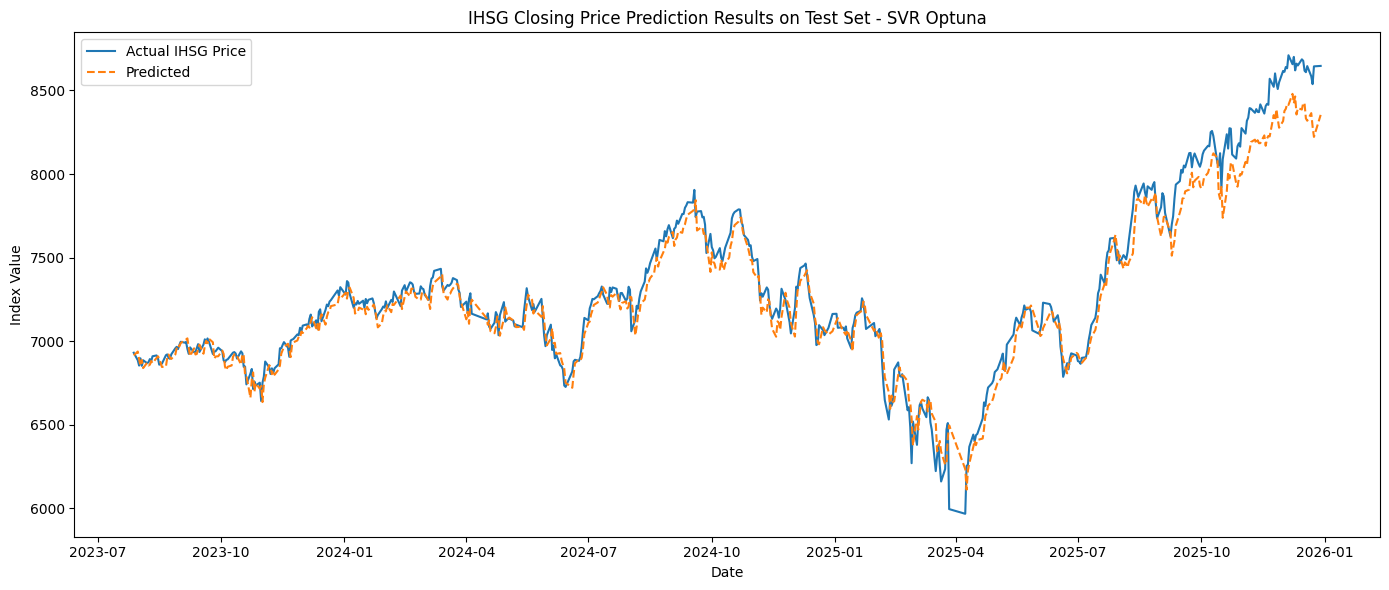

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual IHSG Price", color='#1f77b4', linewidth=1.5)
plt.plot(y_test.index, test_preds, label="Predicted", color='#ff7f0e', linestyle='--', linewidth=1.5)
plt.title("IHSG Closing Price Prediction Results on Test Set - SVR Optuna")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "..", "outputs", "plots", "price_movement_SVR_optuna.png"), dpi=300)
plt.show()